> Confusion matrix ve diğer metrikler ile ilgili küçük bir uygulama, target sütununu tahmin etmeye çalışacağız ve metriklerle başarı oranını ölçeğiz.

In [136]:
import pandas as pd
df=pd.read_csv('metrics_practice_dataset.csv')
df

,age,bmi,blood_pressure,glucose,cholesterol,activity_score,target
0,54,31.6,153.2,129.8,179.3,6.8,1
1,46,36.5,144.6,92.6,199.5,7.6,0
2,56,20.0,129.1,85.1,174.9,4.8,0
3,66,29.8,116.4,107.9,193.3,4.2,1
4,45,23.7,140.6,103.2,133.0,3.1,1
...,...,...,...,...,...,...,...
495,54,25.6,164.1,138.0,235.9,5.7,1
496,36,36.0,165.1,107.3,194.4,6.1,1
497,46,30.2,149.8,83.3,194.4,2.8,1
498,37,24.1,146.4,103.4,235.0,6.2,1


In [137]:
#Verileri ayır

X= df.drop(columns=['target'])
y= df['target'].values

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)


In [138]:
#Modeli eğit ve tahmin yaptır

from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')
clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)


In [139]:
#Modelin başarısını ölç
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
cm = confusion_matrix(y_test,y_pred)
accuracy=accuracy_score(y_test,y_pred)
#Satırlar y_test(gerçek değerler), sütunlar y_pred(tahmin)

report=classification_report(y_test,y_pred)
print(cm)
print('='*50)
print(accuracy)
print('='*50)
print(report)

[[ 0 16]
 [ 1 83]]
0.83
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        16
           1       0.84      0.99      0.91        84

    accuracy                           0.83       100
   macro avg       0.42      0.49      0.45       100
weighted avg       0.70      0.83      0.76       100



* Model 0 değerini hep kaçırdığı için threshold ekliyorum ve 1 demesini biraz da olsa engelliyorum
* Eğer bu gerçekten bir hastalık tahmini olsaydı 0 değerleri önemli olacağından bu tahminleri kaçırmamamız gerekirdi.

In [140]:
y_prob = clf.predict_proba(X_test)[:,1]
y_pred_new= (y_prob >=0.8).astype(int)

cm_new= confusion_matrix(y_test,y_pred_new)
accuracy_new = accuracy_score(y_test,y_pred_new)
report_new = classification_report(y_test,y_pred_new)
print(cm_new)
print('='*50)
print(accuracy_new)
print('='*50)
print(report_new)


[[ 6 10]
 [18 66]]
0.72
              precision    recall  f1-score   support

           0       0.25      0.38      0.30        16
           1       0.87      0.79      0.82        84

    accuracy                           0.72       100
   macro avg       0.56      0.58      0.56       100
weighted avg       0.77      0.72      0.74       100



> Threshold eklememin sonucu olarak model 0 değerleri görmeye başladı fakat 1'lerden feragat etti.

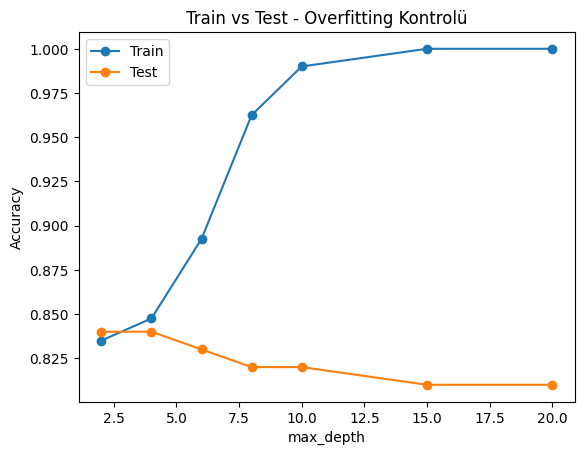

In [141]:
import matplotlib.pyplot as plt

depths = [2, 4, 6, 8, 10, 15, 20]
train_scores = []
test_scores = []

for d in depths:
    clf = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test, y_test))

plt.plot(depths, train_scores, label='Train', marker='o')
plt.plot(depths, test_scores, label='Test', marker='o')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Train vs Test - Overfitting Kontrolü')
plt.legend()
plt.show()

>Modelin ezber yaptığı görülüyor, bunu değiştirmek için eldeki 0 değerlerini yapay olarak arttırmayı deniyorum.

In [142]:
from imblearn.over_sampling import SMOTE

#SMOTE sadece train verisine uygulanır
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train,y_train)
print(pd.Series(y_train_smote).value_counts())

1    334
0    334
Name: count, dtype: int64


In [143]:
clf = RandomForestClassifier(n_estimators=100, random_state=42,max_depth=3)
clf.fit(X_train_smote, y_train_smote)
y_pred_smote = clf.predict(X_test)
cm_smote = confusion_matrix(y_test,y_pred_smote)
accuracy_smote = accuracy_score(y_test,y_pred_smote)
report_smote= classification_report(y_test,y_pred_smote)

In [144]:
print(cm_smote)
print('='*30)
print(accuracy_smote)
print('='*30)
print(report_smote)

[[11  5]
 [28 56]]
0.67
              precision    recall  f1-score   support

           0       0.28      0.69      0.40        16
           1       0.92      0.67      0.77        84

    accuracy                           0.67       100
   macro avg       0.60      0.68      0.59       100
weighted avg       0.82      0.67      0.71       100



# SONUÇ
> Bu örnekte hasta mı değil mi (0-1) değerlerini sınıflandırmaya çalıştım.
* İlk olarak model oluştuğunda 0 değerlerini görmezden geldi ve sadece 1 değerlerini yapmaya çalıştı.
* Bunu önlemek için threshold değeri ekleyerek belirli bir değer olmadan 1 deme diye modele talimat verdim bu sayede model yavaştan 0 değerlerini görmeye başlasa da yaklaşık aynı oranda 1 değerlerini yanlış yaptı/görmedi.
* Bunu daha da arttırmak için SMOTE ile yapay veri ekledim ve modelin derinliğini 3'le sınırladım. Bunun sonucu olarak 0 değerleri görme oranı artsa da tatmin edici bir sonuç vermedi. 
* Modelin tahmin oranını arttırmak için daha farklı algoritmalar (SVM, Logistic Regression) kullanılabilir.